# AppliTemplateion 4 — Landmark Transfer

Landmarks are anatomically meaningful keypoints — a sparse, interpretable subset of the
full dense correspondence.
Given landmarks on the source shape, we find their counterparts on the target shape
using the point-to-point map: for each source landmark j, we find the target vertex i
whose correspondence `p2p[i]` is closest in 3-D to j.

This notebook uses Template → Target as placeholder.
**To use brain or organ shapes**: replace the data loading section and the
landmark indices (or load them from a file).

In [1]:
import gsops.backend as gs
import numpy as np
import pyvista as pv

from geomfum.convert import P2pFromFmConverter
from geomfum.dataset import NotebooksDataset
from geomfum.descriptor.pipeline import (
    ArangeSubsampler,
    DescriptorPipeline,
    L2InnerNormalizer,
)
from geomfum.descriptor.spectral import LandmarkWaveKernelSignature, WaveKernelSignature
from geomfum.functional_map import (
    FactorSum,
    LBCommutativityEnforcing,
    SpectralDescriptorPreservation,
)
from geomfum.numerics.optimization import ScipyMinimize
from geomfum.refine import IcpRefiner
from geomfum.shape import TriangleMesh

pv.set_jupyter_backend("static")


def to_pv(mesh):
    faces = np.hstack([np.full((len(mesh.faces), 1), 3), mesh.faces])
    return pv.PolyData(np.array(mesh.vertices), faces)

## 1. Load shapes and set source landmarks


In [2]:
dataset = NotebooksDataset()
mesh_a = TriangleMesh.from_file(
    dataset.get_filename("brain_template")
)  # source with known landmarks
mesh_b = TriangleMesh.from_file(dataset.get_filename("brain_subject"))  # target
# centering
mesh_a.vertices -= mesh_a.vertices.mean(axis=0)
mesh_b.vertices -= mesh_b.vertices.mean(axis=0)
landmark_a = np.loadtxt(dataset.get_filename("template_ldmk")).astype(int)
landmark_names = [
    "Frontal_Sup_L",
    "Frontal_Sup_R",
    "Precentral_L",
    "Precentral_R",
    "Postcentral_L",
    "Postcentral_R",
]

INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\brain_template.off').


INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\brain_subject.off').
INFO:root:Data has already been downloaded... using cached file ('C:\Users\giuli\.geomfum\data\template_ldmk.txt').


## 2. Compute p2p correspondence

In [3]:
from geomfum.convert import FmFromP2pConverter, NeighborFinder

knn = NeighborFinder()
p2p = knn(mesh_b.vertices, mesh_a.vertices).flatten()

## 3. Transfer landmarks to the target

For each source landmark j, find the target vertex i whose
`p2p[i]`-correspondence is closest (in 3-D) to vertex j.

In [4]:
verts_a = np.array(mesh_a.vertices)
# For each vertex in B, its corresponding position in A:
# correspondence_positions[i] = position of p2p[i] on A
correspondence_positions = verts_a[p2p]  # (n_b, 3)

landmark_b = np.zeros(len(landmark_a), dtype=int)
for k_lm, j in enumerate(landmark_a):
    dists = np.linalg.norm(correspondence_positions - verts_a[j], axis=1)
    landmark_b[k_lm] = np.argmin(dists)

print("Transferred landmarks:")
verts_b = np.array(mesh_b.vertices)
for name, j, i in zip(landmark_names, landmark_a, landmark_b):
    print(
        f"  {name:<15}  Template v{j} {verts_a[j].round(3)}  →  Target v{i} {verts_b[i].round(3)}"
    )

Transferred landmarks:
  Frontal_Sup_L    Template v1449 [-39.537 -51.714 -39.464]  →  Target v1306 [-40.387 -48.722 -36.497]
  Frontal_Sup_R    Template v1369 [-41.522 -53.656 -29.808]  →  Target v1357 [-39.149 -51.152 -28.026]
  Precentral_L     Template v5565 [ 62.397 -31.595  -6.104]  →  Target v5458 [ 58.072 -30.568  -7.358]
  Precentral_R     Template v211 [-67.835 -17.943   0.178]  →  Target v102 [-66.896 -19.148   0.179]
  Postcentral_L    Template v3124 [ 3.469  4.741 80.98 ]  →  Target v3016 [ 0.953  3.972 62.727]
  Postcentral_R    Template v4602 [ 40.718   4.56  -65.998]  →  Target v4225 [ 29.39    8.609 -57.869]


## 4. Visualise landmarks on both shapes

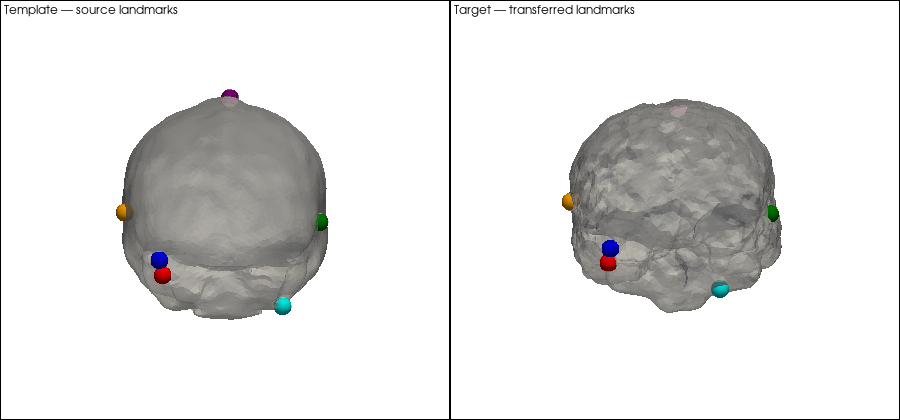

In [5]:
colors = ["red", "blue", "green", "orange", "purple", "cyan"]
point_size = 18

pl = pv.Plotter(shape=(1, 2), window_size=(900, 420))

# Template — source landmarks
pl.subplot(0, 0)
pl.add_mesh(to_pv(mesh_a), color="lightgray", opacity=0.8)
for lm_idx, color, name in zip(landmark_a, colors, landmark_names):
    pt = verts_a[lm_idx].reshape(1, 3)
    pl.add_points(
        pt,
        color=color,
        point_size=point_size,
        render_points_as_spheres=True,
        label=name,
    )
pl.add_text("Template — source landmarks", font_size=9)
pl.camera_position = "xz"

# Target — transferred landmarks
pl.subplot(0, 1)
pl.add_mesh(to_pv(mesh_b), color="lightgray", opacity=0.8)
for lm_idx, color, name in zip(landmark_b, colors, landmark_names):
    pt = verts_b[lm_idx].reshape(1, 3)
    pl.add_points(
        pt,
        color=color,
        point_size=point_size,
        render_points_as_spheres=True,
        label=name,
    )
pl.add_text("Target — transferred landmarks", font_size=9)
pl.camera_position = "xz"

pl.show()
# Each color represents the same anatomical keypoint on both shapes.